# Project 01: Discovering Conservative Patterns in fSHAPE Data
### Artificial Intelligence in Biomedical Informatics

**Authors:**
- Dmytro Romaniv 151958
- Bruno Urbaniak
- Samuel Janas
- Patryk Maciejewski

This notebook covers the extraction, clustering (using KMeans++ and DBSCAN), searching, and visualization of conservative RNA-protein binding sites based on fSHAPE structural data profiles.

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import stumpy
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Steps 1 & 2: Select Protein and Load Expected Motif

In [2]:
# 1. Select the protein to analyze
PROTEIN = 'HNRNPC' # Alternatively, set to 'HNRNPA2B1'
DATA_DIR = f'RBP-footprinting-data/{PROTEIN}'
EXPECTED_FILE = f'{DATA_DIR}/{PROTEIN.lower()}_expected_pattern.txt'
SITES_ZIP = f'{DATA_DIR}/{PROTEIN.lower()}_binding_sites_fshape.zip'
SEARCH_ZIP = f'{DATA_DIR}/{PROTEIN.lower()}_search_fshape.zip'

# 2. Load the expected motif to identify its length (len)
try:
    expected_df = pd.read_csv(EXPECTED_FILE, sep='\t', header=None, names=['fshape', 'base'])
    expected_fshape = expected_df['fshape'].values.astype(np.float64)
    expected_seq = ''.join(expected_df['base'].values)
    w_len = len(expected_fshape)
    print(f'Protein: {PROTEIN}')
    print(f'Expected motif sequence: {expected_seq}')
    print(f'Base length (len): {w_len}')
except FileNotFoundError:
    print('Error: Data files not found. Ensure the directory structure matches the task.')

Protein: HNRNPC
Expected motif sequence: NTTTTN
Base length (len): 6


### Step 3: Determine Motif Lengths

In [3]:
# 3. Determine the length of potentially promising motifs w = {len, len+1, len+2}
W_LIST = [w_len, w_len + 1, w_len + 2]
print(f'Motif lengths to analyze (w): {W_LIST}')

Motif lengths to analyze (w): [6, 7, 8]


### Step 4: Extract Promising Motifs

In [4]:
def read_zip_data(zip_path):
    """Helper function to read tabular data from zipped directories"""
    data_dict = {}
    if not os.path.exists(zip_path):
        return data_dict
    with zipfile.ZipFile(zip_path, 'r') as z:
        for filename in z.namelist():
            if not filename.endswith('.txt'): continue
            with z.open(filename) as f:
                df = pd.read_csv(f, sep='\t', header=None, on_bad_lines='skip')
                if len(df.columns) >= 2:
                    data_dict[filename] = df
    return data_dict

# 4. Extract continuous motifs satisfying max fSHAPE > 1.0
sites_data = read_zip_data(SITES_ZIP)
extracted_motifs = {w: [] for w in W_LIST}

for filename, df in sites_data.items():
    fshape = pd.to_numeric(df[0], errors='coerce').values
    bases = df[1].astype(str).values
    
    for i in range(len(fshape)):
        for w in W_LIST:
            if i + w <= len(fshape):
                window_fshape = fshape[i:i+w]
                # Must be continuous (no NaNs) and max reactivity > 1.0
                if not np.any(np.isnan(window_fshape)):
                    if np.max(window_fshape) > 1.0:
                        extracted_motifs[w].append({
                            'fshape': window_fshape,
                            'seq': ''.join(bases[i:i+w]),
                            'file': filename,
                            'start': i,
                            'end': i+w-1
                        })

for w in W_LIST:
    print(f'Extracted {len(extracted_motifs[w])} valid motifs of length {w}')

Extracted 667 valid motifs of length 6
Extracted 716 valid motifs of length 7
Extracted 757 valid motifs of length 8


### Steps 5 & 6: Cluster Analysis using at least two methods (KMeans++ & DBSCAN)

In [5]:
consensus_profiles = {}

for w in W_LIST:
    if len(extracted_motifs[w]) == 0:
        continue
        
    X = np.array([m['fshape'] for m in extracted_motifs[w]])
    X_norm = StandardScaler().fit_transform(X)
    
    consensus_profiles[w] = []
    
    # --- Method 1: KMeans++ ---
    n_clust = min(8, len(X)) 
    kmeans = KMeans(n_clusters=n_clust, init='k-means++', random_state=42, n_init='auto').fit(X_norm)
    labels_kmeans = kmeans.labels_
    unique_k, counts_k = np.unique(labels_kmeans, return_counts=True)
    # Top 3 clusters with at least 3 elements
    top_clusters_k = [u for u, c in sorted(zip(unique_k, counts_k), key=lambda x: x[1], reverse=True) if c >= 3][:3]
    
    for cl in top_clusters_k:
        idx = np.where(labels_kmeans == cl)[0]
        cons_profile = np.mean(X[idx], axis=0)
        consensus_profiles[w].append({
            'profile': cons_profile,
            'cluster_size': len(idx),
            'method': 'kmeans++'
        })

    # --- Method 2: DBSCAN ---
    dbscan = DBSCAN(eps=0.5, min_samples=3).fit(X_norm)
    labels_dbscan = dbscan.labels_
    unique_d, counts_d = np.unique(labels_dbscan, return_counts=True)
    # Exclude noise (-1) and get top 3 clusters with at least 3 elements
    top_clusters_d = [u for u, c in sorted(zip(unique_d, counts_d), key=lambda x: x[1], reverse=True) if c >= 3 and u != -1][:3]
    
    for cl in top_clusters_d:
        idx = np.where(labels_dbscan == cl)[0]
        cons_profile = np.mean(X[idx], axis=0)
        consensus_profiles[w].append({
            'profile': cons_profile,
            'cluster_size': len(idx),
            'method': 'dbscan'
        })
        
    print(f'Length {w}: Identified {len(top_clusters_k)} KMeans++ and {len(top_clusters_d)} DBSCAN consensus clusters.')

Length 6: Identified 3 KMeans++ and 3 DBSCAN consensus clusters.
Length 7: Identified 3 KMeans++ and 3 DBSCAN consensus clusters.
Length 8: Identified 3 KMeans++ and 3 DBSCAN consensus clusters.


### Step 7: Transcript Search and Scoring

In [6]:
search_data = read_zip_data(SEARCH_ZIP)
results = []
top_match_profile = None # Store the best matching segment for visualization
top_aS = float('inf')

def calc_ssf(seq_expected, seq_target):
    """Calculates sequence similarity factor (ssf) handling 'N' as a wildcard."""
    score = 0
    min_len = min(len(seq_expected), len(seq_target))
    s1, s2 = seq_expected[:min_len], seq_target[:min_len]
    
    purines = {'A', 'G'}
    pyrimidines = {'C', 'U', 'T'}
    
    for b1, b2 in zip(s1, s2):
        if b1 == 'N' or b2 == 'N' or b1 == b2:
            score += 2
        elif (b1 in purines and b2 in purines) or (b1 in pyrimidines and b2 in pyrimidines):
            score += 1
            
    return score / len(seq_expected)

queries = [{'name': 'Expected_Motif', 'profile': expected_fshape, 'length': w_len}]
for w in W_LIST:
    if w in consensus_profiles:
        for i, cons in enumerate(consensus_profiles[w]):
            method = cons['method']
            queries.append({
                'name': f'Consensus_w{w}_{method}_{i+1}',
                'profile': cons['profile'],
                'length': w
            })

for filename, df in search_data.items():
    fshape = pd.to_numeric(df[0], errors='coerce').values
    bases = df[1].astype(str).values
    
    segments, start = [], 0
    for i in range(len(fshape)):
        if np.isnan(fshape[i]):
            if i > start:
                segments.append((start, i))
            start = i + 1
    if start < len(fshape):
        segments.append((start, len(fshape)))
        
    for (seg_start, seg_end) in segments:
        seg_fshape = fshape[seg_start:seg_end].astype(np.float64)
        seg_bases = bases[seg_start:seg_end]
        
        for q in queries:
            m = q['length']
            if len(seg_fshape) >= m:
                try:
                    distances = stumpy.mass(q['profile'], seg_fshape)
                except:
                    continue
                    
                hits = np.where(distances <= 2.5)[0]
                
                for hit in hits:
                    match_seq = ''.join(seg_bases[hit:hit+m])
                    znEd = distances[hit]
                    ssf = calc_ssf(expected_seq, match_seq)
                    aS = 10 * znEd - ssf
                    
                    results.append({
                        'Query Motif': q['name'],
                        'Sequence': match_seq,
                        'Ranges': f'{seg_start + hit} - {seg_start + hit + m - 1}',
                        'Transcript File': filename.split('/')[-1],
                        'znEd': np.round(znEd, 4),
                        'ssf': np.round(ssf, 4),
                        'aS': np.round(aS, 4)
                    })
                    
                    # Capture the absolute best match for the expected motif visualization
                    if aS < top_aS and q['name'] == 'Expected_Motif':
                        top_aS = aS
                        top_match_profile = seg_fshape[hit:hit+m]

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.drop_duplicates(subset=['Ranges', 'Transcript File']).sort_values(by='aS', ascending=True)
    
results_df.head(10)

,Query Motif,Sequence,Ranges,Transcript File,znEd,ssf,aS
3485,Consensus_w7_dbscan_5,TTTTAAA,1291 - 1297,hnrnpc_NM_000067_CA2.txt,0.1408,1.6667,-0.2587
52495,Consensus_w6_kmeans++_3,GAGGGT,945 - 950,hnrnpc_NM_002116_HLA-A.txt,0.0532,0.6667,-0.1348
62555,Consensus_w6_kmeans++_1,GGCGGC,469 - 474,hnrnpc_NM_004826_ECEL1.txt,0.1326,0.8333,0.4928
32771,Consensus_w8_kmeans++_3,GCCGGCAC,1772 - 1779,hnrnpc_NM_001632_ALPP.txt,0.1682,1.0000,0.6820
72627,Consensus_w7_kmeans++_3,GCCAAGA,1617 - 1623,hnrnpc_NM_005860_FSTL3.txt,0.1877,1.0000,0.8767
22880,Consensus_w6_kmeans++_1,AGTTCT,848 - 853,hnrnpc_NM_001308383_DMKN.txt,0.2444,1.5000,0.9444
80039,Consensus_w6_kmeans++_3,GGGCGC,376 - 381,hnrnpc_NM_017527_LY6K.txt,0.1822,0.8333,0.9886
76301,Consensus_w7_dbscan_5,TGCCCTG,488 - 494,hnrnpc_NM_007019_UBE2C.txt,0.2361,1.1667,1.1948
73368,Consensus_w8_kmeans++_3,TGGCGGGG,1918 - 1925,hnrnpc_NM_005860_FSTL3.txt,0.2155,0.8333,1.3217
17730,Consensus_w7_kmeans++_1,GCTACCC,159 - 165,hnrnpc_NM_001195129_PRSS56.txt,0.2732,1.3333,1.3988


### Step 8: Visualization for Presentation

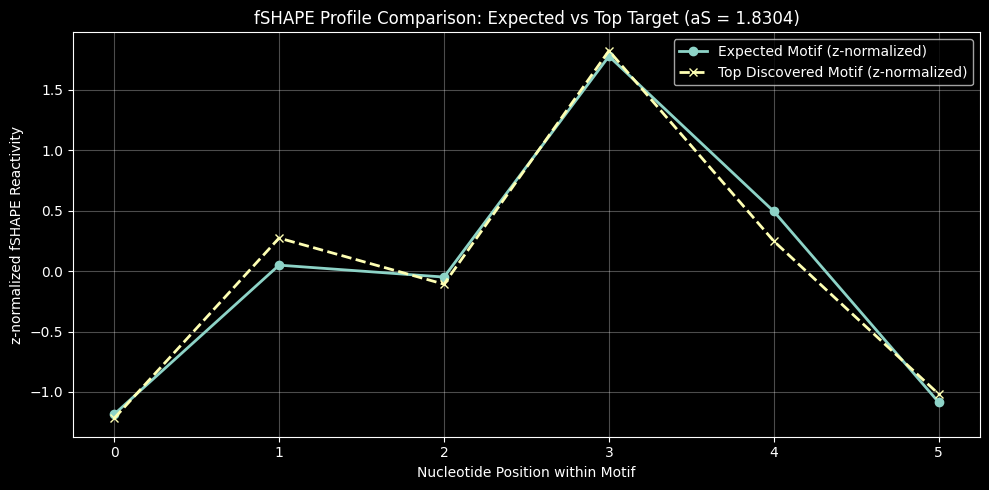

In [7]:
if top_match_profile is not None:
    # Standardize both to visually compare shape regardless of absolute amplitude
    exp_norm = StandardScaler().fit_transform(expected_fshape.reshape(-1, 1)).flatten()
    match_norm = StandardScaler().fit_transform(top_match_profile.reshape(-1, 1)).flatten()
    
    plt.figure(figsize=(10, 5))
    plt.plot(exp_norm, marker='o', label='Expected Motif (z-normalized)', linewidth=2)
    plt.plot(match_norm, marker='x', linestyle='--', label='Top Discovered Motif (z-normalized)', linewidth=2)
    plt.title(f"fSHAPE Profile Comparison: Expected vs Top Target (aS = {top_aS:.4f})")
    plt.xlabel("Nucleotide Position within Motif")
    plt.ylabel("z-normalized fSHAPE Reactivity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No matches found below the threshold for visualization.")